📘연습문제1

In [1]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [6]:
origin = load_data('temperatures_seoul')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/temperatures_seoul.xlsx
[desc] 1973년 7월 1일부터 2023년 8월 6일까지 서울의 일평균 기온 데이터 (출처: 기상청)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (18299, 2)
열 개수: 2
행 개수: 18299

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18299 entries, 0 to 18298
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       18299 non-null  datetime64[ns]
 1   평균기온(℃)  18299 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 286.1 KB
None


,날짜,평균기온(℃)
0,1973-07-01,22.7
1,1973-07-02,23.8
2,1973-07-03,27.2
3,1973-07-04,25.2
4,1973-07-05,26.9


① 데이터 전처리<br>
② 조사기간 동안 변화 분석<br>
③ 기준일 전 1년 데이터 시각화<br>
④ 시계열 모델 적합<br>
⑤ 향후 1년 예측<br>
⑥ 실제 + 예측 시각화


In [19]:
diff_df = origin.copy()

# 날짜를 인덱스로 설정
diff_df.set_index('날짜', inplace=True)


In [22]:
# 정상성 검정 + 차분(칼럼 단위로)
yname = '평균기온(℃)'
diff_count = 0
result = []

while True:
    ar = adfuller(diff_df[yname])

    ar_dict = {
        '차수': diff_count,
        'ADF Statistic': ar[0],
        'p-value': ar[1],
        'result': ar[1] <= 0.05
    }
    result.append(ar_dict)

    if ar_dict['result']:
        break

    diff_count += 1
    diff_df[yname] = diff_df[yname].diff()
    diff_df = diff_df.dropna()


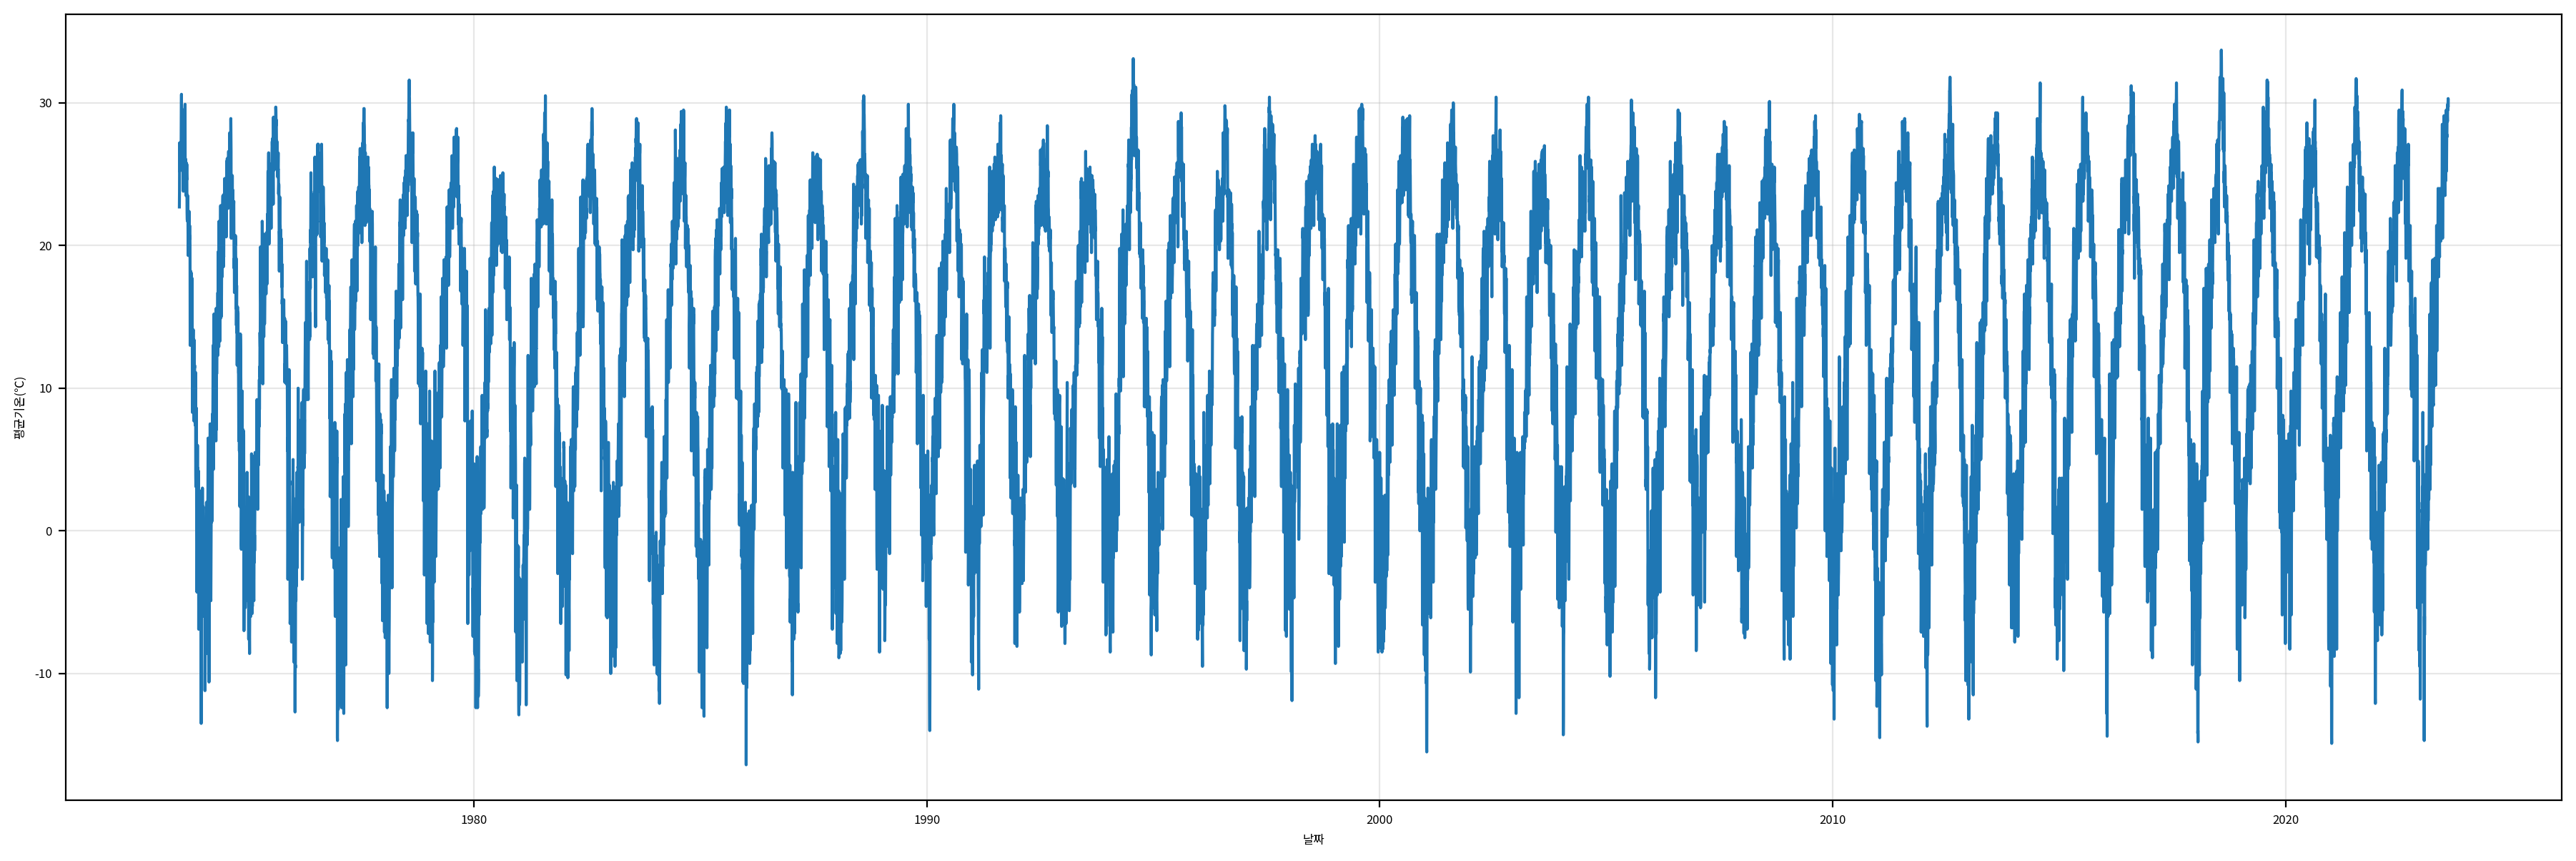

In [24]:


fig, ax = plt.subplots(figsize=(18, 6), dpi=my_dpi)

sb.lineplot(
    data=diff_df,
    x=diff_df.index,
    y=yname,
    ax=ax
)


ax.set_xlabel('날짜')
ax.set_ylabel(yname)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


,차수,ADF Statistic,p-value,result
0,0,-13.650422,1.589753e-25,True
1,0,-13.650422,1.589753e-25,True
2,0,-13.650422,1.589753e-25,True
3,0,-13.650422,1.589753e-25,True
4,0,-13.650422,1.589753e-25,True
5,0,-13.650422,1.589753e-25,True
6,0,-13.650422,1.589753e-25,True
7,0,-13.650422,1.589753e-25,True
8,0,-13.650422,1.589753e-25,True


,평균기온(℃)
날짜,
1973-07-01,22.7
1973-07-02,23.8
1973-07-03,27.2
1973-07-04,25.2
1973-07-05,26.9


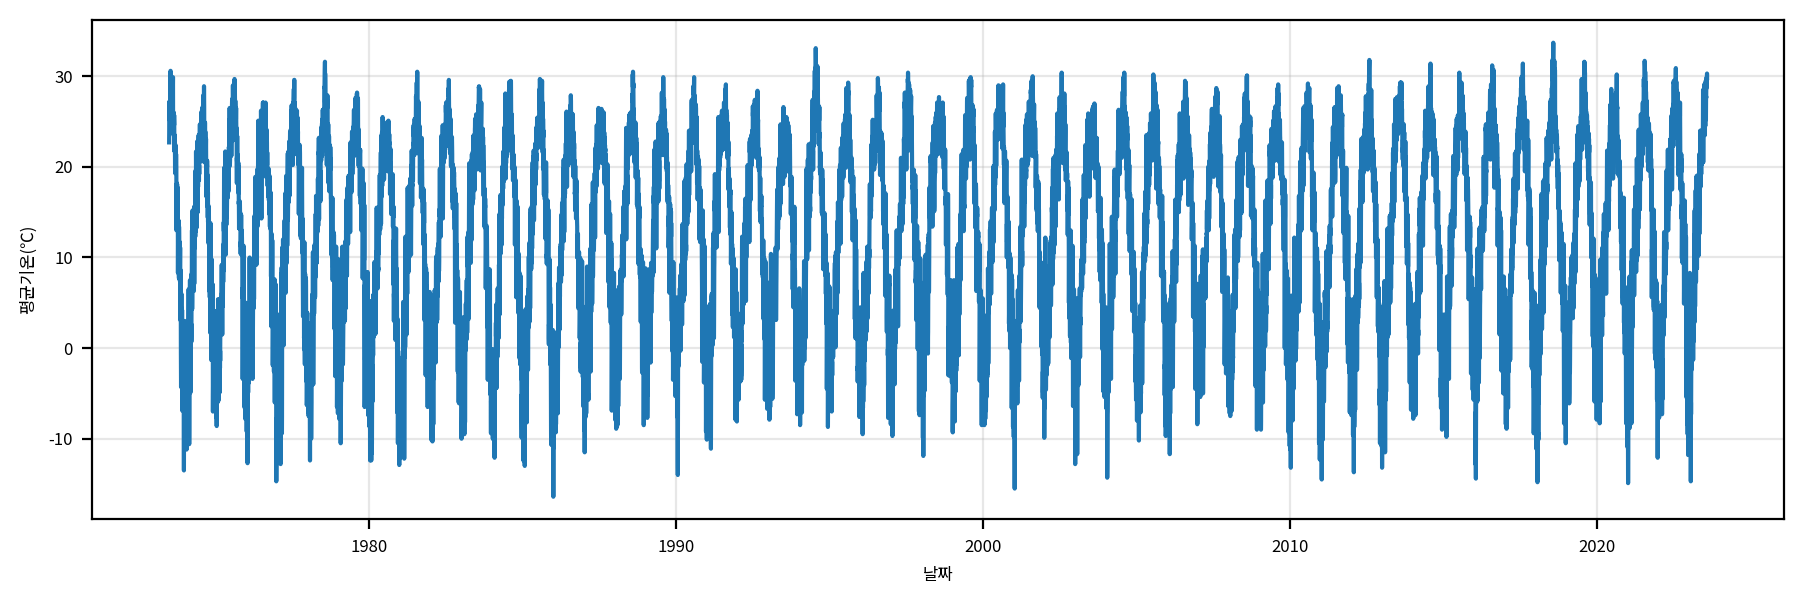

-----장기추세-----
장기적으로 평균이 크게 이동하지 않았다.


-----계절성-----
1년 주기(365일)로 반복되는 패턴이 매우 명확
여름 최고,겨울 최저
진폭도 거의 일정


-----분산-----
시간에 따라 분산이 폭발하지 않음
이분산성도 크지 않음
단위근 존재하지 않음



In [32]:
while True:
    ar = adfuller(diff_df[yname])

    ar_dict = {
        '차수': diff_count,
        'ADF Statistic': ar[0],
        'p-value': ar[1],
        'result': True if ar[1] <= 0.05 else False
    }

    # 리스트에 정상성 검사 결과 저장
    result.append(ar_dict)

    # 정상성 충족 시 반복 종료
    if ar_dict['result']:
        break

    # 정상성이 충족되지 않았다면 차분 수행 후 다시 실행
    diff_count += 1
    diff_df = diff_df.diff().dropna()

# 차분 결과표
display(DataFrame(result))

# 차분 결과 생성된 데이터프레임
display(diff_df.head())

# 차분 결과 시각화
width_px = 1800
height_px = 600
rows = 1
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

sb.lineplot(
    data=diff_df,
    x=diff_df.index,
    y=yname,
    ax=ax
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()
print(f"-----장기추세-----\n장기적으로 평균이 크게 이동하지 않았다.\n"
      f"\n\n-----계절성-----\n1년 주기(365일)로 반복되는 패턴이 매우 명확\n"
      f"여름 최고,겨울 최저\n"
      f"진폭도 거의 일정\n"
      f"\n\n-----분산-----\n"
      f"시간에 따라 분산이 폭발하지 않음\n이분산성도 크지 않음\n단위근 존재하지 않음\n")


3. 기준선(임계값)과 직접 비교해 보자<br>
| 유의수준 | 임계값|<br>
| ---- | ------- |<br>
| 10%  | 약 −2.57 |<br>
| 5%   | 약 −2.86 |<br>
| 1%   | 약 −3.43 |


In [44]:
# 데이터 전처리
import pandas as pd
df = origin.copy()
df['날짜'] = pd.to_datetime(df['날짜'])
df.set_index('날짜', inplace=True)
df = df.sort_index()


In [48]:
# 기준일 ±1년 데이터 추출
base_date = pd.Timestamp('2023-08-06')

past_1y = df.loc[base_date - pd.DateOffset(years=1) : base_date]

past_1y

,평균기온(℃)
날짜,
2022-08-06,28.7
2022-08-07,28.9
2022-08-08,26.8
2022-08-09,25.1
2022-08-10,24.7
...,...
2023-08-02,29.7
2023-08-03,29.5
2023-08-04,30.0


$\|vert acf|\rvert>\frac{2}{\sqrt{N}}$

In [35]:
# 수치값 계산
acf_vals = acf(diff_df['평균기온(℃)'])

threshold = 2/np.sqrt(len(diff_df['평균기온(℃)']))

significant_lags = np.where(np.abs(acf_vals) > threshold)[0]

acf_vals, threshold, significant_lags

(array([1.        , 0.97460883, 0.94511196, 0.9285472 , 0.91947465,
        0.91415534, 0.91047678, 0.90711596, 0.90431141, 0.90151724,
        0.89828911, 0.89492715, 0.89218382, 0.88971586, 0.88621878,
        0.8817201 , 0.87665684, 0.87173518, 0.86543075, 0.85909572,
        0.85396835, 0.84895901, 0.84364515, 0.8380976 , 0.83146641,
        0.82433827, 0.81706648, 0.80907861, 0.80096077, 0.79250169,
        0.78439652, 0.77635241, 0.76815485, 0.75976287, 0.75072567,
        0.74139934, 0.73204298, 0.72248294, 0.71327381, 0.70422507,
        0.69432189, 0.68418413, 0.67366168]),
 np.float64(0.014784829381697078),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42]))

각 lag에서 자기상관이 통계적으로 유의한가?<br>
ACF 값의 특징<br>
🍭lag 0 = 1(자기자신 ---> 당연)<br>
🍭아주 천천히 감소<br>

유의 임계값<br>
🍭threshold ≈ 0.0148<br>
🍭즉, |ACF| > 0.0148이면 유의<br>
그런데 lag 1부터 42까지 전부 유의

과거 1년 평균기온 시계열

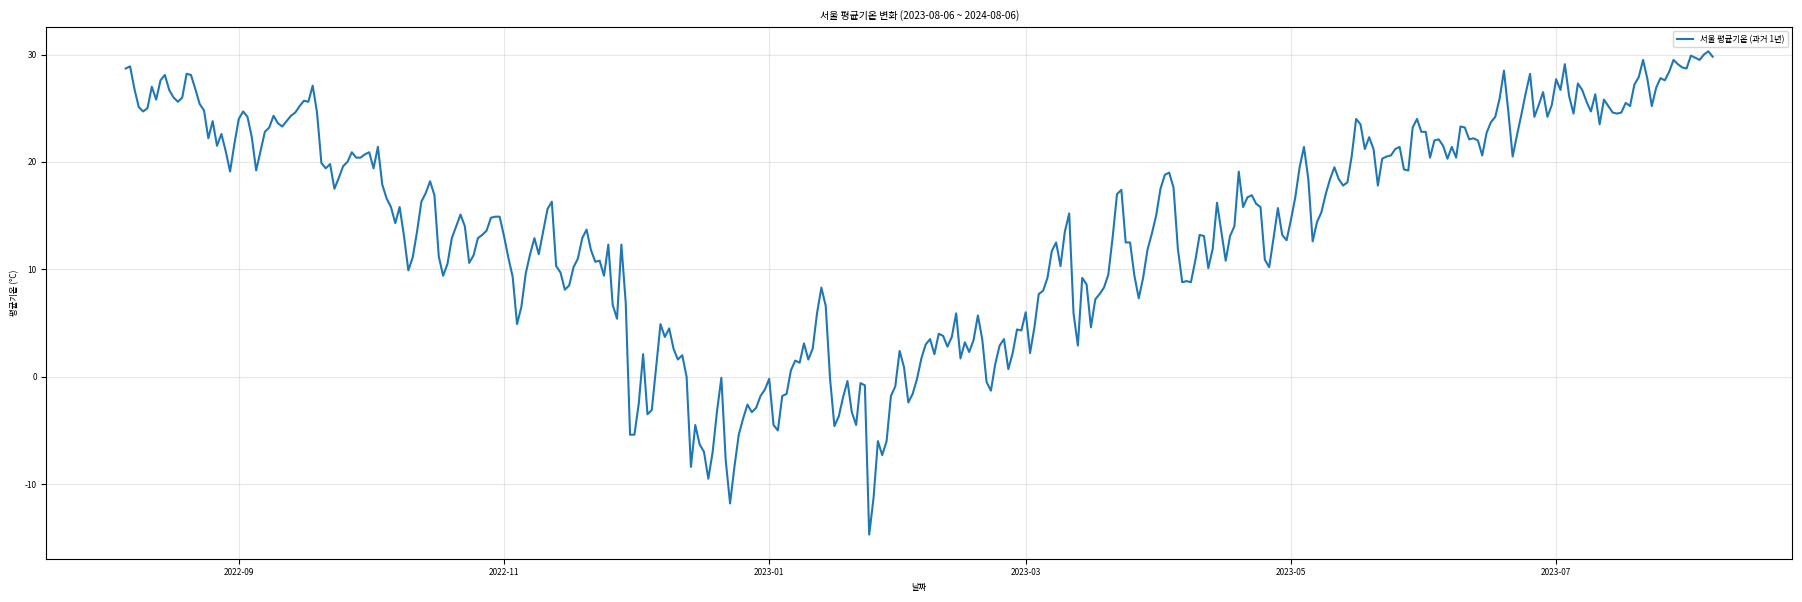

여름만 놓고 보았을 때, 2023년도 보다 2024년도 여름철 기온이 더 높음


In [57]:
fig, ax = plt.subplots(figsize=(18,6))

ax.plot(
    past_1y.index,
    past_1y['평균기온(℃)'],
    label='서울 평균기온 (과거 1년)'
)

ax.set_title('서울 평균기온 변화 (2023-08-06 ~ 2024-08-06)')
ax.set_xlabel('날짜')
ax.set_ylabel('평균기온 (°C)')

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
print(f"여름만 놓고 보았을 때, 2023년도 보다 2024년도 여름철 기온이 더 높음")

7일 이동평균 추가(노이즈 제거)

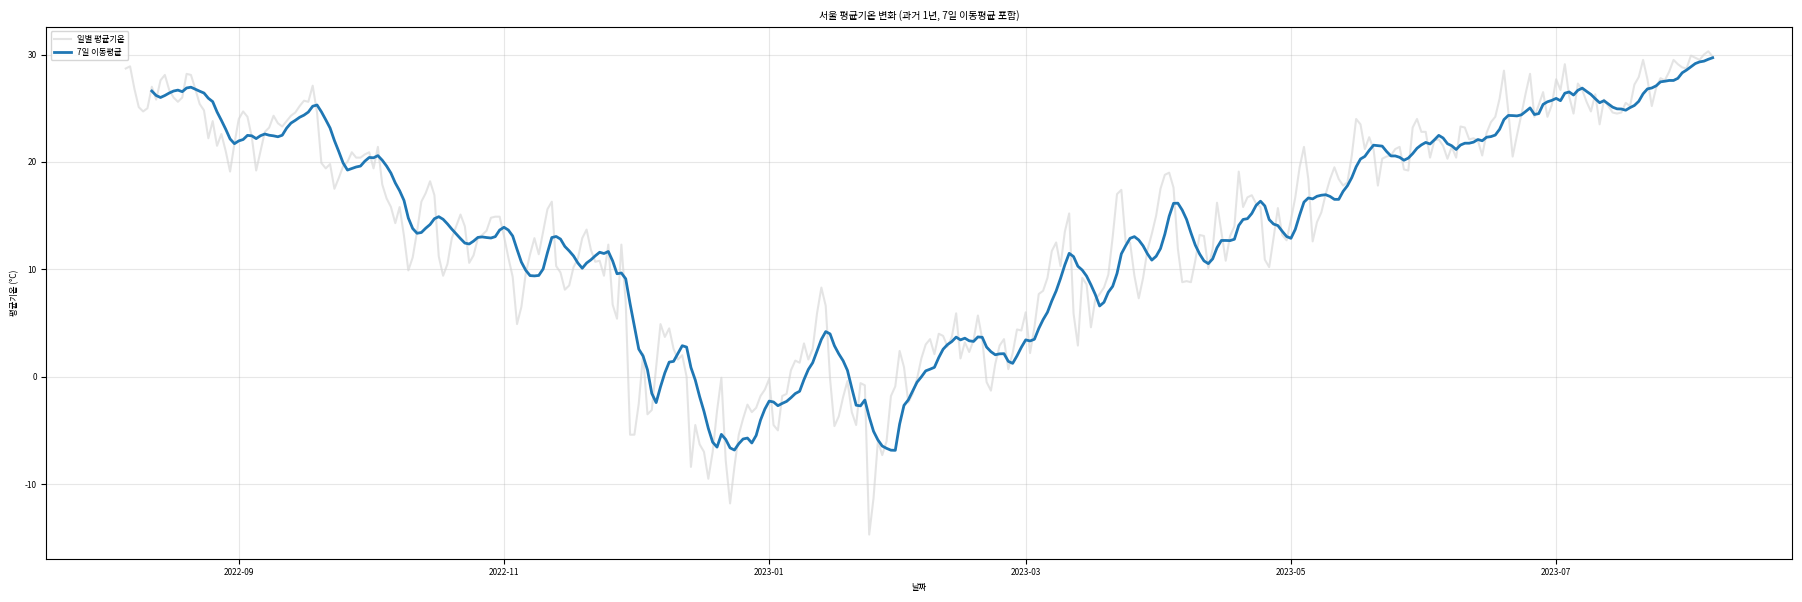

왜☀️여름철☀️에만 7일 이동평균과 일별 기온이 다르게 느껴질까?
여름 기온의 분포 특성 때문
--->상방 왜도가 큼
평소:27~30℃, 폭염일:33~37℃ (극단값)
즉, 높은 쪽으로 튀는 값이 자주 발생
7일 이동평균은 이런 극단값을 희석시킴

-----이동평균의 구조적 한계-----
7일 이동평균은 본질적으로:
극단적인 고온을 낮게 보이게 만드는 필터


In [64]:
past_1y_ma7 = past_1y['평균기온(℃)'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(18,6))

ax.plot(
    past_1y.index,
    past_1y['평균기온(℃)'],
    color='lightgray',
    alpha=0.6,
    label='일별 평균기온'
)

ax.plot(
    past_1y.index,
    past_1y_ma7,
    linewidth=2,
    label='7일 이동평균'
)

ax.set_title('서울 평균기온 변화 (과거 1년, 7일 이동평균 포함)')
ax.set_xlabel('날짜')
ax.set_ylabel('평균기온 (°C)')

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
print(f"왜☀️여름철☀️에만 7일 이동평균과 일별 기온이 다르게 느껴질까?\n"
      f"여름 기온의 분포 특성 때문\n"
      f"--->상방 왜도가 큼\n평소:27~30℃, 폭염일:33~37℃ (극단값)\n즉, 높은 쪽으로 튀는 값이 자주 발생\n7일 이동평균은 이런 극단값을 희석시킴\n\n-----이동평균의 구조적 한계-----\n7일 이동평균은 본질적으로:\n극단적인 고온을 낮게 보이게 만드는 필터")

In [89]:
# 여름 기간 정의
summer_2023 = df.loc['2023-06-01':'2023-08-31']
summer_2024 = df.loc['2024-06-01':'2024-08-31']

# 평균 비교
summer_2023['평균기온(℃)'].mean()
summer_2024['평균기온(℃)'].mean()


print(summer_2023.max())

평균기온(℃)    30.3
dtype: float64


In [91]:
summer_2024.max()

평균기온(℃)   NaN
dtype: float64

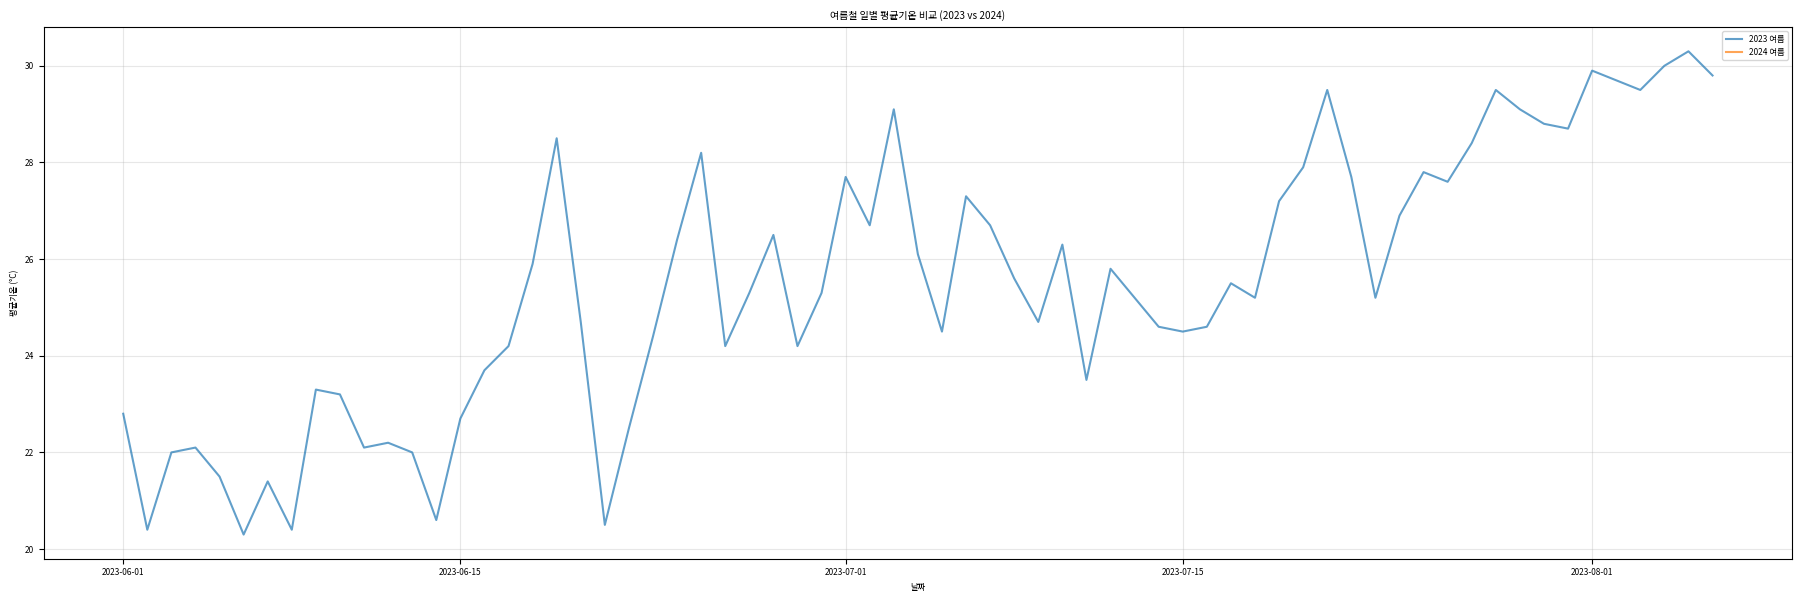

In [83]:
# 2023,2024 두 해 여름 시계열 비교 그래프
fig, ax = plt.subplots(figsize=(18,6))

ax.plot(
    summer_2023.index,
    summer_2023['평균기온(℃)'],
    label='2023 여름',
    alpha=0.7
)

ax.plot(
    summer_2024.index,
    summer_2024['평균기온(℃)'],
    label='2024 여름',
    alpha=0.7
)

ax.set_title('여름철 일별 평균기온 비교 (2023 vs 2024)')
ax.set_xlabel('날짜')
ax.set_ylabel('평균기온 (°C)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
# 폭염일 정의
heat_threshold = 33

In [87]:


# 연도별 폭염일 개수 계산
heat_days_2023 = (summer_2023['평균기온(℃)'] >= heat_threshold).sum()
heat_days_2024 = (summer_2024['평균기온(℃)'] >= heat_threshold).sum()

heat_days_2023, heat_days_2024

(np.int64(0), np.int64(0))

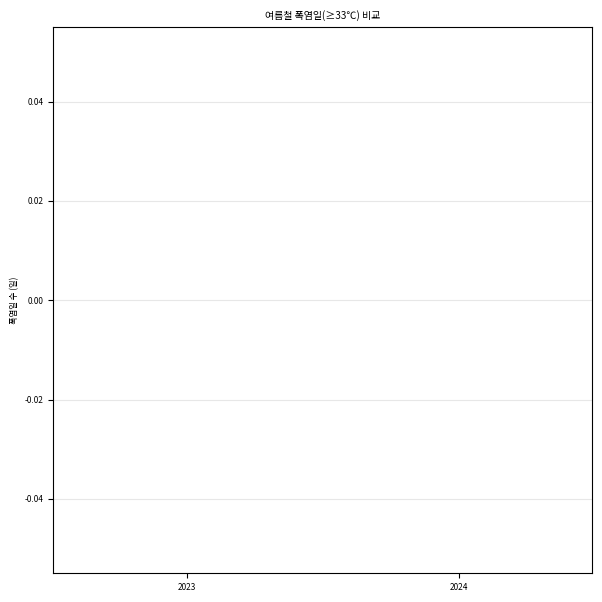

In [93]:
fig, ax = plt.subplots(figsize=(6,6))

ax.bar(
    ['2023', '2024'],
    [heat_days_2023, heat_days_2024]
)

ax.set_title('여름철 폭염일(≥33℃) 비교')
ax.set_ylabel('폭염일 수 (일)')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


일평균 기온 기준으로 33℃ 이상의 폭염일은 분석기간 동안 관측되지 않음.<br>
이는 폭염 기준이 일반적으로 일 최고기온을 기준으로 정의되기 때문이며,<br> 평균기온을 활용한 분석에서는<br>
고온일 기준을 재정의할 필요가 있어보임
